# Graph Neural Networks from Scratch

This notebook implements a complete GNN pipeline using only NumPy. There is no PyTorch, no TensorFlow, no PyTorch Geometric. Every weight matrix, every forward pass, every gradient is computed by hand.

**Why this matters:** Libraries like PyTorch Geometric compress an entire GCN layer into a single line of code. That is convenient for production work, but it hides the mechanics. If you want to understand what a GNN is actually doing -- how messages flow between nodes, how gradients propagate through a graph convolution, why the normalized adjacency matrix matters -- you need to see the raw operations.

**What you will need:**
- NumPy (matrix math)
- Matplotlib (plotting)
- Pandas (data display)
- NetworkX (graph construction and algorithms)
- Neo4j (optional, for graph database sections)

**What you will NOT need:**
- PyTorch, TensorFlow, or any deep learning framework
- PyTorch Geometric or DGL

If you have not read the main notebook (`Knowledge_Graph_GNN_Neo4j_Guide.ipynb`), start there. It covers the theory in depth. This notebook focuses on implementation from first principles.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import random
from collections import defaultdict
from matplotlib.patches import Patch

np.random.seed(42)
random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('All dependencies loaded. No deep learning frameworks required.')

All dependencies loaded. No deep learning frameworks required.


---

## See It First: A GNN in Action

Before we dive into logistics networks and matrix math, let us watch a Graph Neural Network work on something you already understand -- a group of friends.

We have 8 people. Some are friends, some are not. Each person has a few interests. The question is: **who should we recommend as new friends?**

A GNN answers this by letting each person "learn" from their friends. After a few rounds of sharing information with neighbors, people who end up with similar representations are likely to get along -- even if they have never met.

Let us watch this happen step by step.

In [ ]:
# ==============================================================
# Step 1: Build a Small Friend Network
# ==============================================================

friends = nx.Graph()

# 8 people with interests as features
people = {
    'Alice':   {'music': 1, 'sports': 0, 'cooking': 1, 'gaming': 0},
    'Bob':     {'music': 1, 'sports': 1, 'cooking': 0, 'gaming': 0},
    'Charlie': {'music': 0, 'sports': 1, 'cooking': 0, 'gaming': 1},
    'Diana':   {'music': 0, 'sports': 0, 'cooking': 1, 'gaming': 1},
    'Eve':     {'music': 1, 'sports': 0, 'cooking': 1, 'gaming': 0},
    'Frank':   {'music': 0, 'sports': 1, 'cooking': 0, 'gaming': 1},
    'Grace':   {'music': 1, 'sports': 1, 'cooking': 0, 'gaming': 0},
    'Hank':    {'music': 0, 'sports': 0, 'cooking': 1, 'gaming': 1},
}

for name, interests in people.items():
    friends.add_node(name, **interests)

# Friendships (edges)
friendships = [
    ('Alice', 'Bob'),       # music in common
    ('Alice', 'Eve'),       # music + cooking
    ('Bob', 'Charlie'),     # sports in common
    ('Bob', 'Grace'),       # music + sports
    ('Charlie', 'Frank'),   # sports + gaming
    ('Diana', 'Hank'),      # cooking + gaming
    ('Diana', 'Eve'),       # cooking in common
    ('Frank', 'Hank'),      # gaming in common
    ('Grace', 'Charlie'),   # sports in common
]
friends.add_edges_from(friendships)

# Layout
pos = nx.spring_layout(friends, seed=42, k=2.0)

# Draw
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
nx.draw(friends, pos, ax=ax, with_labels=True,
        node_color='#4ECDC4', node_size=1200, font_size=12,
        font_weight='bold', edge_color='#999999', width=2,
        edgecolors='white', linewidths=2)
ax.set_title('Our Friend Network — Who Knows Who?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Show interests table
interest_df = pd.DataFrame(people).T
interest_df.index.name = 'Person'
print('Each person\'s interests (1 = yes, 0 = no):')
print(interest_df.to_string())
print(f'\nFriendships: {friends.number_of_edges()}')
print(f'Question: Who should we recommend as new friends?')


### Step 2: Message Passing — Each Person Learns From Their Friends

This is the core of how a GNN works. In each round (called a "layer"), every person collects their friends' interest profiles and averages them together with their own. After one round, you know what your direct friends like. After two rounds, you also know what your friends' friends like.

Let us trace this for Alice:
- **Before GNN:** Alice knows her own interests: music and cooking
- **After Layer 1:** Alice averages in Bob's and Eve's interests (her direct friends)
- **After Layer 2:** Alice now also has indirect information about Charlie, Grace, and Diana (friends of her friends)

Watch how the numbers change:

In [ ]:
# ==============================================================
# Step 2: Message Passing — Watch Information Flow
# ==============================================================

# Build feature matrix and normalized adjacency (same math we use later)
names = sorted(friends.nodes())
n = len(names)
name_to_i = {name: i for i, name in enumerate(names)}

# Feature matrix: each row is a person's interests
features = ['music', 'sports', 'cooking', 'gaming']
H0 = np.array([[friends.nodes[name][f] for f in features] for name in names], dtype=float)

# Normalized adjacency (A + I, then symmetric normalization)
A = nx.adjacency_matrix(friends, nodelist=names).toarray().astype(float)
A_tilde = A + np.eye(n)
D_inv_sqrt = np.diag(1.0 / np.sqrt(A_tilde.sum(axis=1)))
A_hat = D_inv_sqrt @ A_tilde @ D_inv_sqrt

# Layer 1: just multiply by A_hat (message passing without learned weights)
H1 = A_hat @ H0

# Layer 2: another round of message passing
H2 = A_hat @ H1

# Show the progression for each person
print('BEFORE GNN (raw interests):')
print(pd.DataFrame(H0, index=names, columns=features).round(2).to_string())

print('\nAFTER LAYER 1 (each person averaged in their friends\' interests):')
print(pd.DataFrame(H1, index=names, columns=features).round(3).to_string())

print('\nAFTER LAYER 2 (information from friends-of-friends):')
print(pd.DataFrame(H2, index=names, columns=features).round(3).to_string())

print('\n--- Trace for Alice ---')
ai = name_to_i['Alice']
print(f'  Before:  {dict(zip(features, H0[ai]))}')
print(f'  Layer 1: {dict(zip(features, H1[ai].round(3)))}')
print(f'  Layer 2: {dict(zip(features, H2[ai].round(3)))}')
print(f'  Alice\'s friends: {list(friends.neighbors("Alice"))}')
print(f'  After 2 layers, Alice\'s representation reflects the broader network around her.')


### Step 3: Predicting New Friendships

Now the key insight: after message passing, people who end up with **similar representations** are likely to get along -- even if they are not currently friends.

We measure similarity with a dot product. Higher score = more compatible. Let us check every pair of people who are NOT currently friends and see who the GNN thinks should be introduced.

In [ ]:
# ==============================================================
# Step 3: Predict New Friendships
# ==============================================================

# Compute similarity scores for all NON-friend pairs
existing_edges = set(friends.edges())
existing_edges.update((v, u) for u, v in friends.edges())

recommendations = []
for i in range(n):
    for j in range(i + 1, n):
        if (names[i], names[j]) not in existing_edges:
            # Dot product of their Layer-2 representations
            score = H2[i] @ H2[j]
            # Count mutual friends
            mutual = len(set(friends.neighbors(names[i])) & set(friends.neighbors(names[j])))
            recommendations.append({
                'Person 1': names[i],
                'Person 2': names[j],
                'GNN Score': round(score, 3),
                'Mutual Friends': mutual,
            })

rec_df = pd.DataFrame(recommendations).sort_values('GNN Score', ascending=False)
print('Friend Recommendations (ranked by GNN similarity):')
print('=' * 58)
print(rec_df.to_string(index=False))
print(f'\nTop recommendation: {rec_df.iloc[0]["Person 1"]} and {rec_df.iloc[0]["Person 2"]}')
print(f'  GNN score: {rec_df.iloc[0]["GNN Score"]}')
print(f'  Mutual friends: {rec_df.iloc[0]["Mutual Friends"]}')


In [ ]:
# ==============================================================
# Visualize: Before and After Message Passing
# ==============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Panel 1: Original graph with raw features ---
ax1 = axes[0]
nx.draw(friends, pos, ax=ax1, with_labels=True,
        node_color='#4ECDC4', node_size=1000, font_size=10,
        font_weight='bold', edge_color='#999999', width=2,
        edgecolors='white', linewidths=2)
ax1.set_title('Original Network', fontsize=14, fontweight='bold')

# --- Panel 2: After message passing, color by similarity to Alice ---
ax2 = axes[1]
alice_emb = H2[name_to_i['Alice']]
similarities = np.array([H2[name_to_i[name]] @ alice_emb for name in names])
sim_normalized = (similarities - similarities.min()) / (similarities.max() - similarities.min())

# Color map: green (similar to Alice) to gray (different)
colors = [plt.cm.YlGn(0.3 + 0.7 * s) for s in sim_normalized]

nx.draw(friends, pos, ax=ax2, with_labels=True,
        node_color=colors, node_size=1000, font_size=10,
        font_weight='bold', edge_color='#999999', width=2,
        edgecolors='white', linewidths=2)
ax2.set_title('Similarity to Alice\n(greener = more similar)', fontsize=14, fontweight='bold')

# --- Panel 3: Predicted new friendships ---
ax3 = axes[2]
nx.draw(friends, pos, ax=ax3, with_labels=True,
        node_color='#4ECDC4', node_size=1000, font_size=10,
        font_weight='bold', edge_color='#cccccc', width=1.5,
        edgecolors='white', linewidths=2)

# Draw top 3 predicted edges as dashed red lines
top3 = rec_df.head(3)
for _, row in top3.iterrows():
    p1, p2 = row['Person 1'], row['Person 2']
    x1, y1 = pos[p1]
    x2, y2 = pos[p2]
    ax3.plot([x1, x2], [y1, y2], color='#e74c3c', linewidth=2.5,
            linestyle='--', alpha=0.8, zorder=0)

# Legend for predicted edges
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#999999', linewidth=2, label='Existing friendship'),
    Line2D([0], [0], color='#e74c3c', linewidth=2.5, linestyle='--', label='Predicted new friendship'),
]
ax3.legend(handles=legend_elements, loc='lower center', fontsize=9)
ax3.set_title('Top 3 Friend Recommendations\n(red dashed = predicted)', fontsize=14, fontweight='bold')

plt.suptitle('GNN in Action: From Raw Interests to Friend Recommendations',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### What Just Happened?

In three steps, we built a working GNN that predicts new friendships:

1. **We represented people as feature vectors** -- each person's interests became a row of numbers
2. **We ran message passing** -- each person averaged in their friends' features, then their friends-of-friends' features
3. **We measured similarity** -- people whose representations ended up close together after message passing are good friend candidates

Notice that the GNN found recommendations that make intuitive sense. People with mutual friends and overlapping interests scored highest -- but the model figured this out entirely from the graph structure and the features. We never told it the rule "mutual friends means compatible." It learned that pattern from the message passing.

**This is the same process we will use for the rest of the notebook**, just at a larger scale with a logistics network instead of a friend group, and with learned weight matrices instead of simple averaging.

---

---

## Part 1: Building the Logistics Knowledge Graph

We build the same UPS logistics network from the main notebook. This section is intentionally brief -- see the main notebook for the full treatment of knowledge graph theory, Neo4j setup, and Cypher queries.

The graph we build here will be the same graph we feed into our from-scratch GNN in Part 3. This is the critical bridge: a knowledge graph is how you *model* connected data; a GNN is how you *learn* from it.

In [2]:
# ==============================================================
# Build the UPS Logistics Knowledge Graph
# ==============================================================

logistics_graph = nx.Graph()

# --- Facility nodes ---
facilities = [
    ('HUB_Louisville',   {'type': 'hub',         'capacity': 2000, 'region': 'central'}),
    ('HUB_Chicago',      {'type': 'hub',         'capacity': 1500, 'region': 'central'}),
    ('HUB_Dallas',       {'type': 'hub',         'capacity': 1200, 'region': 'south'}),
    ('AIR_Anchorage',    {'type': 'air_gateway',  'capacity': 800,  'region': 'west'}),
    ('AIR_Ontario',      {'type': 'air_gateway',  'capacity': 900,  'region': 'west'}),
    ('AIR_Philadelphia', {'type': 'air_gateway',  'capacity': 700,  'region': 'east'}),
    ('DEP_Nashville',    {'type': 'depot',        'capacity': 300,  'region': 'central'}),
    ('DEP_Memphis',      {'type': 'depot',        'capacity': 350,  'region': 'south'}),
    ('DEP_Portland',     {'type': 'depot',        'capacity': 250,  'region': 'west'}),
    ('DEP_Atlanta',      {'type': 'depot',        'capacity': 400,  'region': 'south'}),
    ('DEP_Denver',       {'type': 'depot',        'capacity': 280,  'region': 'central'}),
    ('DEP_Boston',       {'type': 'depot',        'capacity': 320,  'region': 'east'}),
]

# --- Package nodes (in transit) ---
packages = []
priorities = ['standard', 'express', 'next_day_air']
weights = [1.5, 3.0, 0.5, 12.0, 7.5, 2.2, 0.8, 5.5, 9.1, 4.4,
           6.3, 1.1, 8.8, 3.3, 11.2, 0.9, 7.7, 2.8, 4.6, 10.0]
for i in range(20):
    packages.append((
        f'PKG_{i:04d}',
        {'type': 'package', 'priority': random.choice(priorities),
         'weight_lbs': weights[i], 'capacity': 0, 'region': 'transit'}
    ))

logistics_graph.add_nodes_from(facilities)
logistics_graph.add_nodes_from(packages)

# --- Facility-to-facility routes ---
routes = [
    ('HUB_Louisville', 'HUB_Chicago',      {'mode': 'ground', 'distance_mi': 265}),
    ('HUB_Louisville', 'HUB_Dallas',        {'mode': 'air',    'distance_mi': 726}),
    ('HUB_Louisville', 'AIR_Anchorage',     {'mode': 'air',    'distance_mi': 3200}),
    ('HUB_Louisville', 'AIR_Philadelphia',  {'mode': 'air',    'distance_mi': 585}),
    ('HUB_Louisville', 'DEP_Nashville',     {'mode': 'ground', 'distance_mi': 175}),
    ('HUB_Louisville', 'DEP_Memphis',       {'mode': 'ground', 'distance_mi': 375}),
    ('HUB_Chicago',    'DEP_Denver',        {'mode': 'ground', 'distance_mi': 920}),
    ('HUB_Chicago',    'DEP_Boston',        {'mode': 'air',    'distance_mi': 860}),
    ('HUB_Dallas',     'DEP_Atlanta',       {'mode': 'ground', 'distance_mi': 780}),
    ('HUB_Dallas',     'DEP_Memphis',       {'mode': 'ground', 'distance_mi': 450}),
    ('AIR_Ontario',    'DEP_Portland',      {'mode': 'air',    'distance_mi': 960}),
    ('AIR_Ontario',    'HUB_Dallas',        {'mode': 'air',    'distance_mi': 1200}),
    ('AIR_Anchorage',  'AIR_Ontario',       {'mode': 'air',    'distance_mi': 2350}),
    ('AIR_Philadelphia','DEP_Boston',        {'mode': 'ground', 'distance_mi': 300}),
    ('DEP_Nashville',  'DEP_Atlanta',       {'mode': 'ground', 'distance_mi': 250}),
]
logistics_graph.add_edges_from(routes)

# --- Assign packages to random facilities ---
facility_names = [f[0] for f in facilities]
for pkg_name, _ in packages:
    assigned = random.choice(facility_names)
    logistics_graph.add_edge(pkg_name, assigned, mode='located_at', distance_mi=0)

print(f'Logistics graph: {logistics_graph.number_of_nodes()} nodes, '
      f'{logistics_graph.number_of_edges()} edges')
print(f'  Facilities: {len(facilities)}')
print(f'  Packages:   {len(packages)}')

Logistics graph: 32 nodes, 35 edges
  Facilities: 12
  Packages:   20


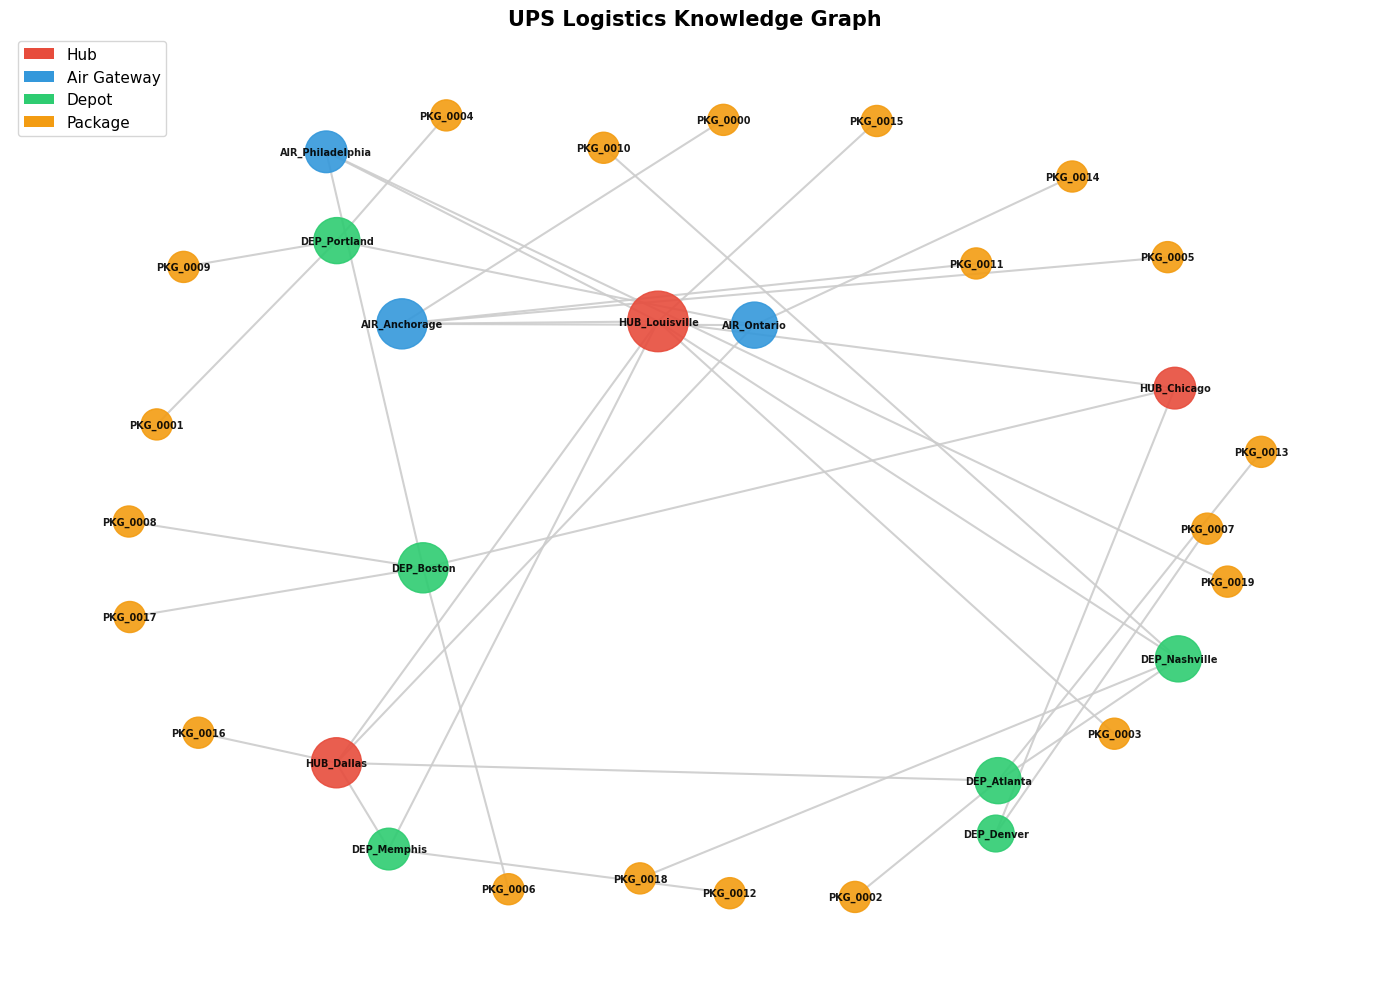

In [3]:
# ==============================================================
# Visualize the Knowledge Graph
# ==============================================================

type_colors = {
    'hub':         '#e74c3c',
    'air_gateway': '#3498db',
    'depot':       '#2ecc71',
    'package':     '#f39c12',
}

node_colors = [type_colors[logistics_graph.nodes[n].get('type', 'package')]
               for n in logistics_graph.nodes()]
node_sizes = [300 + 200 * logistics_graph.degree(n) for n in logistics_graph.nodes()]

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
pos = nx.spring_layout(logistics_graph, seed=42, k=1.8)

nx.draw(logistics_graph, pos, ax=ax,
        node_color=node_colors, node_size=node_sizes,
        with_labels=True, font_size=7, font_weight='bold',
        edge_color='#cccccc', width=1.5, alpha=0.9)

legend_elements = [Patch(facecolor=c, label=t.replace('_', ' ').title())
                   for t, c in type_colors.items()]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)
ax.set_title('UPS Logistics Knowledge Graph', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# ==============================================================
# Optional: Load into Neo4j
# ==============================================================

NEO4J_URI      = 'bolt://localhost:7687'
NEO4J_USER     = 'neo4j'
NEO4J_PASSWORD = 'password123'   # <-- change to your password

neo4j_available = False
driver = None

try:
    from neo4j import GraphDatabase
    driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
    driver.verify_connectivity()
    neo4j_available = True
    print('Connected to Neo4j successfully!')
except Exception as e:
    print(f'Neo4j not available: {e}')
    print('Continuing with NetworkX only -- all code below still works.')


def run_cypher(query, parameters=None):
    """Run a Cypher query and return results. Returns [] if Neo4j is unavailable."""
    if driver is None:
        return []
    with driver.session() as session:
        result = session.run(query, parameters or {})
        return [record.data() for record in result]


# Load nodes into Neo4j (if available)
if neo4j_available:
    run_cypher('MATCH (n) DETACH DELETE n')  # clean slate
    for name, data in logistics_graph.nodes(data=True):
        label = data.get('type', 'package').capitalize()
        run_cypher(
            f'MERGE (n:{label} {{name: $name}}) SET n += $props',
            {'name': name, 'props': data}
        )
    for u, v, data in logistics_graph.edges(data=True):
        run_cypher(
            'MATCH (a {name: $u}), (b {name: $v}) '
            'MERGE (a)-[r:CONNECTS_TO]->(b) SET r += $props',
            {'u': u, 'v': v, 'props': data}
        )
    print(f'Loaded {logistics_graph.number_of_nodes()} nodes and '
          f'{logistics_graph.number_of_edges()} edges into Neo4j.')
else:
    print('Skipping Neo4j load. See main notebook for full Neo4j walkthrough.')

Connected to Neo4j successfully!
Loaded 32 nodes and 35 edges into Neo4j.


### Key Queries: Cypher vs. NetworkX

Here are two essential queries shown in both languages. For the full set of queries, see Section 5 of the main notebook.

In [6]:
# ==============================================================
# Query 1: Which hub has the most packages?
# ==============================================================

# --- Cypher version ---
cypher_q1 = """
MATCH (p:Package)-[:CONNECTS_TO]-(h:Hub)
RETURN h.name AS hub, COUNT(p) AS package_count
ORDER BY package_count DESC
"""
print('Cypher query:')
print(cypher_q1)

if neo4j_available:
    results = run_cypher(cypher_q1)
    for r in results:
        print(f"  {r['hub']}: {r['package_count']} packages")

# --- NetworkX version (always works) ---
print('NetworkX equivalent:')
hub_counts = defaultdict(int)
for node, data in logistics_graph.nodes(data=True):
    if data.get('type') == 'package':
        for neighbor in logistics_graph.neighbors(node):
            if logistics_graph.nodes[neighbor].get('type') == 'hub':
                hub_counts[neighbor] += 1

for hub, count in sorted(hub_counts.items(), key=lambda x: -x[1]):
    print(f'  {hub}: {count} packages')

Cypher query:

MATCH (p:Package)-[:CONNECTS_TO]-(h:Hub)
RETURN h.name AS hub, COUNT(p) AS package_count
ORDER BY package_count DESC

  HUB_Louisville: 2 packages
  HUB_Dallas: 1 packages
NetworkX equivalent:
  HUB_Louisville: 2 packages
  HUB_Dallas: 1 packages


In [7]:
# ==============================================================
# Query 2: Shortest path between two facilities
# ==============================================================

# --- Cypher version ---
cypher_q2 = """
MATCH path = shortestPath(
  (a {name: 'DEP_Portland'})-[*]-(b {name: 'DEP_Boston'})
)
RETURN [n IN nodes(path) | n.name] AS route, length(path) AS hops
"""
print('Cypher query:')
print(cypher_q2)

if neo4j_available:
    results = run_cypher(cypher_q2)
    for r in results:
        print(f"  Route: {' -> '.join(r['route'])}")

# --- NetworkX version ---
print('NetworkX equivalent:')
path = nx.shortest_path(logistics_graph, 'DEP_Portland', 'DEP_Boston')
print(f'  Route: {" -> ".join(path)}')
print(f'  Hops: {len(path) - 1}')

Cypher query:

MATCH path = shortestPath(
  (a {name: 'DEP_Portland'})-[*]-(b {name: 'DEP_Boston'})
)
RETURN [n IN nodes(path) | n.name] AS route, length(path) AS hops

  Route: DEP_Portland -> AIR_Ontario -> HUB_Dallas -> HUB_Louisville -> HUB_Chicago -> DEP_Boston
NetworkX equivalent:
  Route: DEP_Portland -> AIR_Ontario -> HUB_Dallas -> HUB_Louisville -> HUB_Chicago -> DEP_Boston
  Hops: 5


---

## Part 2: From Knowledge Graph to Matrices

This is the step that most tutorials skip. We have a knowledge graph with labeled nodes, typed edges, and properties. A neural network needs numbers -- matrices of floats. This section shows exactly how to make that conversion.

By the end of this section, we will have:
- A **node feature matrix** `X` of shape `[N, F]` where N is the number of nodes and F is the number of features
- An **adjacency matrix** `A` of shape `[N, N]`
- A **normalized adjacency matrix** `A_hat` that the GCN will actually use
- A **label vector** `y` of shape `[N]` for node classification

In [8]:
# ==============================================================
# Build the Node Feature Matrix X
# ==============================================================
#
# Each node becomes a row in a matrix. Each property becomes one
# or more columns. Categorical properties get one-hot encoded;
# numerical properties get normalized to [0, 1].
#
# Feature layout (15 dimensions):
#   [0:4]   one-hot node type   (hub, air_gateway, depot, package)
#   [4]     normalized capacity
#   [5:10]  one-hot region      (central, south, west, east, transit)
#   [10]    normalized degree
#   [11]    normalized weight
#   [12:15] one-hot priority    (standard, express, next_day_air)

node_list = sorted(logistics_graph.nodes())
node_to_idx = {n: i for i, n in enumerate(node_list)}
N = len(node_list)
F = 15  # total features

type_map     = {'hub': 0, 'air_gateway': 1, 'depot': 2, 'package': 3}
region_map   = {'central': 0, 'south': 1, 'west': 2, 'east': 3, 'transit': 4}
priority_map = {'standard': 0, 'express': 1, 'next_day_air': 2}

max_capacity = max(d.get('capacity', 1) for _, d in logistics_graph.nodes(data=True))
max_degree   = max(dict(logistics_graph.degree()).values())
max_weight   = max(d.get('weight_lbs', 1) for _, d in logistics_graph.nodes(data=True))

X = np.zeros((N, F), dtype=np.float64)

for node, data in logistics_graph.nodes(data=True):
    i = node_to_idx[node]
    ntype = data.get('type', 'package')

    # One-hot node type (cols 0-3)
    X[i, type_map[ntype]] = 1.0

    # Normalized capacity (col 4)
    X[i, 4] = data.get('capacity', 0) / max_capacity

    # One-hot region (cols 5-9)
    region = data.get('region', 'transit')
    X[i, 5 + region_map[region]] = 1.0

    # Normalized degree (col 10)
    X[i, 10] = logistics_graph.degree(node) / max_degree

    # Normalized weight for packages (col 11)
    X[i, 11] = data.get('weight_lbs', 0) / max_weight

    # One-hot priority for packages (cols 12-14)
    if ntype == 'package':
        pri = data.get('priority', 'standard')
        X[i, 12 + priority_map[pri]] = 1.0

print(f'Node feature matrix X shape: {X.shape}  (N={N}, F={F})')
print(f'\nSample rows:')
sample_idx = [0, 1, N//2, N-1]
for idx in sample_idx:
    print(f'  {node_list[idx]:20s} -> {X[idx]}')

Node feature matrix X shape: (32, 15)  (N=32, F=15)

Sample rows:
  AIR_Anchorage        -> [0.    1.    0.    0.    0.4   0.    0.    1.    0.    0.    0.625 0.
 0.    0.    0.   ]
  AIR_Ontario          -> [0.   1.   0.   0.   0.45 0.   0.   1.   0.   0.   0.5  0.   0.   0.
 0.  ]
  PKG_0004             -> [0.    0.    0.    1.    0.    0.    0.    0.    0.    1.    0.125 0.625
 0.    1.    0.   ]
  PKG_0019             -> [0.         0.         0.         1.         0.         0.
 0.         0.         0.         1.         0.125      0.83333333
 1.         0.         0.        ]


### Building and Normalizing the Adjacency Matrix

The raw adjacency matrix `A` has a 1 wherever two nodes are connected. But a GCN does not use `A` directly. It uses a **normalized** version called `A_hat` that does two things:

1. **Self-loops** (`A + I`): Without self-loops, a node's own features would be ignored during message passing -- it would only see its neighbors. Adding the identity matrix ensures each node also "sends a message to itself."

2. **Symmetric normalization** (`D^{-1/2} * A_tilde * D^{-1/2}`): Without normalization, nodes with many connections (like a major hub) would accumulate much larger values than nodes with few connections (like a small depot). The normalization scales each entry so that the aggregation is a weighted average rather than a sum.

In [9]:
# ==============================================================
# Build Adjacency Matrix and Normalize It
# ==============================================================

# Raw adjacency matrix
A = nx.adjacency_matrix(logistics_graph, nodelist=node_list).toarray().astype(np.float64)

# Step 1: Add self-loops
A_tilde = A + np.eye(N)

# Step 2: Compute degree of A_tilde
degrees = A_tilde.sum(axis=1)  # row sums

# Step 3: D^{-1/2}
D_inv_sqrt = np.diag(1.0 / np.sqrt(degrees))

# Step 4: Symmetric normalization
A_hat = D_inv_sqrt @ A_tilde @ D_inv_sqrt

print(f'Adjacency matrix A shape:          {A.shape}')
print(f'Normalized adjacency A_hat shape:   {A_hat.shape}')
print(f'A_hat is symmetric:                 {np.allclose(A_hat, A_hat.T)}')
print(f'A_hat diagonal (self-loop weights): {A_hat.diagonal()[:5].round(3)} ...')
print(f'A_hat row sums (should vary):       {A_hat.sum(axis=1)[:5].round(3)} ...')

Adjacency matrix A shape:          (32, 32)
Normalized adjacency A_hat shape:   (32, 32)
A_hat is symmetric:                 True
A_hat diagonal (self-loop weights): [0.167 0.2   0.25  0.2   0.167] ...
A_hat row sums (should vary):       [1.351 1.081 0.974 1.215 1.441] ...


In [10]:
# ==============================================================
# Generate Synthetic Labels (Delay Risk)
# ==============================================================
#
# Label 0 = on-time, Label 1 = delayed
# We use the same heuristic as the main notebook:
#   - next_day_air packages -> higher risk
#   - heavy packages -> higher risk
#   - low-capacity depots -> higher risk
#   - high-degree (congested) nodes -> higher risk
#   - plus random noise for realism

y = np.zeros(N, dtype=np.int64)

for node, data in logistics_graph.nodes(data=True):
    i = node_to_idx[node]
    risk_score = 0.0

    if data.get('type') == 'package':
        if data.get('priority') == 'next_day_air':
            risk_score += 0.35
        if data.get('weight_lbs', 0) > 8.0:
            risk_score += 0.25

    cap = data.get('capacity', 0)
    if 0 < cap < 350:
        risk_score += 0.3

    deg = logistics_graph.degree(node)
    if deg >= 5:
        risk_score += 0.2

    risk_score += np.random.uniform(-0.15, 0.15)
    y[i] = 1 if risk_score > 0.3 else 0

print(f'Label distribution:')
print(f'  On-time (0): {(y == 0).sum()}')
print(f'  Delayed (1): {(y == 1).sum()}')

Label distribution:
  On-time (0): 24
  Delayed (1): 8


In [11]:
# ==============================================================
# Train / Test Split
# ==============================================================

perm = np.random.permutation(N)
train_size = int(0.7 * N)
train_mask = np.zeros(N, dtype=bool)
test_mask = np.zeros(N, dtype=bool)
train_mask[perm[:train_size]] = True
test_mask[perm[train_size:]] = True

print(f'Train nodes: {train_mask.sum()}')
print(f'Test nodes:  {test_mask.sum()}')

Train nodes: 22
Test nodes:  10


In [12]:
# ==============================================================
# Summary: Everything the GNN Needs
# ==============================================================

print('Data ready for GNN training')
print('=' * 50)
print(f'  Node feature matrix X:     {X.shape}')
print(f'  Normalized adjacency A_hat: {A_hat.shape}')
print(f'  Labels y:                  {y.shape}')
print(f'  Train / Test:              {train_mask.sum()} / {test_mask.sum()}')
print()
print('Sample nodes:')
sample_df = pd.DataFrame({
    'Node': [node_list[i] for i in range(min(8, N))],
    'Type': [logistics_graph.nodes[node_list[i]].get('type', '?') for i in range(min(8, N))],
    'Degree': [logistics_graph.degree(node_list[i]) for i in range(min(8, N))],
    'Label': [y[i] for i in range(min(8, N))],
    'Split': ['train' if train_mask[i] else 'test' for i in range(min(8, N))],
})
print(sample_df.to_string(index=False))

Data ready for GNN training
  Node feature matrix X:     (32, 15)
  Normalized adjacency A_hat: (32, 32)
  Labels y:                  (32,)
  Train / Test:              22 / 10

Sample nodes:
            Node        Type  Degree  Label Split
   AIR_Anchorage air_gateway       5      0 train
     AIR_Ontario air_gateway       4      0  test
AIR_Philadelphia air_gateway       3      0 train
     DEP_Atlanta       depot       4      0  test
      DEP_Boston       depot       5      1 train
      DEP_Denver       depot       2      0 train
     DEP_Memphis       depot       3      0  test
   DEP_Nashville       depot       4      0 train


---

## Part 3: Building a GCN from Scratch

Before we build the full GCN, we need the basic building blocks that PyTorch normally provides: activation functions, loss functions, and their gradients. We implement each one as a plain Python function operating on NumPy arrays.

### Activation Functions

In [13]:
# ==============================================================
# ReLU Activation and Its Gradient
# ==============================================================

def relu(x):
    """ReLU activation: max(0, x), applied element-wise."""
    return np.maximum(0, x)

def relu_grad(x):
    """Gradient of ReLU: 1 where x > 0, else 0."""
    return (x > 0).astype(np.float64)


# Quick test
test_input = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])
print('ReLU test:')
print(f'  Input:    {test_input}')
print(f'  Output:   {relu(test_input)}')
print(f'  Gradient: {relu_grad(test_input)}')

ReLU test:
  Input:    [-2.  -0.5  0.   0.5  2. ]
  Output:   [0.  0.  0.  0.5 2. ]
  Gradient: [0. 0. 0. 1. 1.]


In [14]:
# ==============================================================
# Softmax
# ==============================================================

def softmax(logits):
    """Numerically stable softmax over the last axis.

    Input:  logits of shape [N, C]
    Output: probabilities of shape [N, C], each row sums to 1
    """
    # Subtract max for numerical stability (prevents overflow in exp)
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_shifted = np.exp(shifted)
    return exp_shifted / exp_shifted.sum(axis=1, keepdims=True)


# Quick test
test_logits = np.array([[2.0, 1.0, 0.1], [-1.0, 2.0, 3.0]])
test_probs = softmax(test_logits)
print('Softmax test:')
print(f'  Input logits:\n    {test_logits}')
print(f'  Output probs:\n    {test_probs.round(4)}')
print(f'  Row sums: {test_probs.sum(axis=1).round(6)}  (should be [1, 1])')

Softmax test:
  Input logits:
    [[ 2.   1.   0.1]
 [-1.   2.   3. ]]
  Output probs:
    [[0.659  0.2424 0.0986]
 [0.0132 0.2654 0.7214]]
  Row sums: [1. 1.]  (should be [1, 1])


In [15]:
# ==============================================================
# Cross-Entropy Loss and Its Gradient
# ==============================================================

def cross_entropy_loss(probs, labels):
    """Negative log-likelihood loss for classification.

    probs:  [N, C] probability matrix (output of softmax)
    labels: [N] integer labels

    Returns: scalar loss (mean over nodes)
    """
    n = len(labels)
    log_probs = np.log(probs[np.arange(n), labels] + 1e-12)
    return -log_probs.mean()


def cross_entropy_grad(probs, labels):
    """Gradient of cross-entropy loss w.r.t. the logits (before softmax).

    When combined with softmax, the gradient simplifies to:
        dL/d(logits) = probs - one_hot(labels)

    This is one of the cleanest results in ML math. The derivation:
    softmax turns logits into probs, cross-entropy compares probs to
    the true label. The chain rule through both operations cancels
    most terms, leaving just (predicted - actual).

    Returns: [N, C] gradient matrix
    """
    n = len(labels)
    grad = probs.copy()
    grad[np.arange(n), labels] -= 1.0
    grad /= n
    return grad


# Quick test
test_labels = np.array([0, 2])  # correct classes
loss = cross_entropy_loss(test_probs, test_labels)
grad = cross_entropy_grad(test_probs, test_labels)
print('Cross-entropy test:')
print(f'  Probs:    {test_probs.round(4)}')
print(f'  Labels:   {test_labels}')
print(f'  Loss:     {loss:.4f}')
print(f'  Gradient: {grad.round(4)}')
print(f'  (gradient is small where prediction matches label)')

Cross-entropy test:
  Probs:    [[0.659  0.2424 0.0986]
 [0.0132 0.2654 0.7214]]
  Labels:   [0 2]
  Loss:     0.3718
  Gradient: [[-0.1705  0.1212  0.0493]
 [ 0.0066  0.1327 -0.1393]]
  (gradient is small where prediction matches label)


### The GCN Layer

A single GCN layer computes:

```
H' = ReLU(A_hat @ H @ W + b)
```

where:
- `A_hat` is the normalized adjacency matrix `[N, N]` (fixed, not learned)
- `H` is the input node feature matrix `[N, F_in]`
- `W` is a learnable weight matrix `[F_in, F_out]`
- `b` is a learnable bias vector `[F_out]`
- The output `H'` has shape `[N, F_out]`

That is the entire layer. Three matrix multiplications, a bias addition, and a ReLU. The key insight is that multiplying by `A_hat` mixes each node's features with its neighbors' features -- that is the "message passing."

Let us trace what happens to a single node v:
1. `A_hat @ H`: For row v of the result, this computes a weighted average of node v's own features and all its neighbors' features (the weights come from the normalized adjacency)
2. `(A_hat @ H) @ W`: This projects the mixed features through a learnable linear transformation
3. `ReLU(...)`: This adds non-linearity

In PyTorch Geometric, this entire operation is one line: `x = self.conv1(x, edge_index)`. Here, we write it out.

In [16]:
# ==============================================================
# GCN Layer — From Scratch
# ==============================================================

class GCNLayer:
    """A single Graph Convolutional Network layer, implemented with NumPy.

    Forward:  H' = activation(A_hat @ H @ W + b)
    """

    def __init__(self, in_features, out_features, activation=True):
        """
        in_features:  number of input features per node
        out_features: number of output features per node
        activation:   whether to apply ReLU (False for the final layer)
        """
        # Xavier/Glorot initialization
        scale = np.sqrt(2.0 / (in_features + out_features))
        self.W = np.random.randn(in_features, out_features) * scale
        self.b = np.zeros(out_features)
        self.use_activation = activation

        # Gradient accumulators (filled during backward pass)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

        # Cache for backward pass
        self.H_in = None      # input to this layer
        self.Z = None          # pre-activation output
        self.H_out = None      # post-activation output

    def forward(self, A_hat, H):
        """
        A_hat: normalized adjacency [N, N]
        H:     input features [N, in_features]

        Returns: output features [N, out_features]
        """
        self.H_in = H
        self.Z = A_hat @ H @ self.W + self.b

        if self.use_activation:
            self.H_out = relu(self.Z)
        else:
            self.H_out = self.Z.copy()

        return self.H_out

    def backward(self, A_hat, dH_out):
        """
        Backpropagate gradients through this layer.

        A_hat:   normalized adjacency [N, N]
        dH_out:  gradient of loss w.r.t. this layer's output [N, out_features]

        Returns: dH_in -- gradient w.r.t. this layer's input [N, in_features]
        """
        # Step 1: Gradient through activation
        if self.use_activation:
            dZ = dH_out * relu_grad(self.Z)
        else:
            dZ = dH_out

        # Step 2: Gradient w.r.t. weights and bias
        # Forward was: Z = A_hat @ H_in @ W + b
        # So: dW = (A_hat @ H_in)^T @ dZ
        AH = A_hat @ self.H_in
        self.dW = AH.T @ dZ
        self.db = dZ.sum(axis=0)

        # Step 3: Gradient w.r.t. input (to pass to previous layer)
        # dH_in = A_hat^T @ dZ @ W^T
        # A_hat is symmetric so A_hat^T = A_hat
        dH_in = A_hat @ dZ @ self.W.T

        return dH_in


print('GCNLayer class defined.')
print('  Forward:  H\' = activation(A_hat @ H @ W + b)')
print('  Backward: computes dW, db, and passes dH to previous layer')

GCNLayer class defined.
  Forward:  H' = activation(A_hat @ H @ W + b)
  Backward: computes dW, db, and passes dH to previous layer


### Understanding the Backward Pass

The forward pass computes `Z = A_hat @ H @ W + b`. To train the network, we need three gradients:

**Gradient w.r.t. W** (to update the weights):
```
dL/dW = (A_hat @ H)^T @ dL/dZ
```
This follows from the chain rule for matrix multiplication. If `Z = M @ W` where `M = A_hat @ H`, then `dZ/dW = M^T`.

**Gradient w.r.t. b** (to update the bias):
```
dL/db = sum over rows of dL/dZ
```
The bias is added to every row, so its gradient is the sum of all row gradients.

**Gradient w.r.t. H** (to pass to the previous layer):
```
dL/dH = A_hat^T @ dL/dZ @ W^T
```
Note that `A_hat^T = A_hat` because our symmetric normalization produces a symmetric matrix. This means the backward message passing uses the same adjacency structure as the forward pass.

In [17]:
# ==============================================================
# Full GCN Model — 3 Layers
# ==============================================================

class GCNModel:
    """A multi-layer GCN for node classification, built entirely with NumPy.

    Architecture:
        Layer 1: GCNLayer(in_features, 32) + ReLU
        Layer 2: GCNLayer(32, 16) + ReLU
        Layer 3: GCNLayer(16, num_classes) + Softmax
    """

    def __init__(self, in_features, hidden1, hidden2, num_classes):
        self.layer1 = GCNLayer(in_features, hidden1, activation=True)
        self.layer2 = GCNLayer(hidden1, hidden2, activation=True)
        self.layer3 = GCNLayer(hidden2, num_classes, activation=False)
        self.layers = [self.layer1, self.layer2, self.layer3]

    def forward(self, A_hat, X):
        """Full forward pass. Returns softmax probabilities [N, C]."""
        H = self.layer1.forward(A_hat, X)
        H = self.layer2.forward(A_hat, H)
        logits = self.layer3.forward(A_hat, H)
        probs = softmax(logits)
        return probs

    def backward(self, A_hat, probs, labels, mask):
        """Full backward pass. Computes gradients for all layers.

        Only computes loss over nodes in `mask` (train nodes).
        """
        # Gradient of softmax + cross-entropy w.r.t. logits
        dLogits = cross_entropy_grad(probs, labels)

        # Zero out gradients for non-training nodes
        dLogits[~mask] = 0.0

        # Backprop through layers in reverse order
        dH = self.layer3.backward(A_hat, dLogits)
        dH = self.layer2.backward(A_hat, dH)
        dH = self.layer1.backward(A_hat, dH)

    def get_embeddings(self, A_hat, X):
        """Return 16-dim embeddings from layer 2 (for visualization)."""
        H = self.layer1.forward(A_hat, X)
        H = self.layer2.forward(A_hat, H)
        return H

    def count_parameters(self):
        """Total number of learnable parameters."""
        total = 0
        for layer in self.layers:
            total += layer.W.size + layer.b.size
        return total


# Instantiate
model = GCNModel(
    in_features=X.shape[1],  # 15
    hidden1=32,
    hidden2=16,
    num_classes=2
)

print('GCN Model (from scratch, NumPy only)')
print('=' * 45)
print(f'  Layer 1: [{X.shape[1]}, 32] + ReLU')
print(f'  Layer 2: [32, 16] + ReLU')
print(f'  Layer 3: [16, 2] + Softmax')
print(f'  Total parameters: {model.count_parameters()}')
print(f'    Layer 1: {model.layer1.W.size + model.layer1.b.size} '
      f'(W: {model.layer1.W.shape}, b: {model.layer1.b.shape})')
print(f'    Layer 2: {model.layer2.W.size + model.layer2.b.size} '
      f'(W: {model.layer2.W.shape}, b: {model.layer2.b.shape})')
print(f'    Layer 3: {model.layer3.W.size + model.layer3.b.size} '
      f'(W: {model.layer3.W.shape}, b: {model.layer3.b.shape})')

GCN Model (from scratch, NumPy only)
  Layer 1: [15, 32] + ReLU
  Layer 2: [32, 16] + ReLU
  Layer 3: [16, 2] + Softmax
  Total parameters: 1074
    Layer 1: 512 (W: (15, 32), b: (32,))
    Layer 2: 528 (W: (32, 16), b: (16,))
    Layer 3: 34 (W: (16, 2), b: (2,))


### Training: The Adam Optimizer from Scratch

In the main notebook, `torch.optim.Adam(model.parameters(), lr=0.01)` handles all of this in one line. Here we implement Adam ourselves.

Adam maintains two running averages for each parameter:
- **m** (first moment): a smoothed estimate of the gradient (momentum)
- **v** (second moment): a smoothed estimate of the squared gradient (adaptive learning rate)

Parameters that consistently receive large gradients get smaller effective learning rates (because `v` is large). Parameters that receive sparse, infrequent gradients get larger effective learning rates. This makes Adam well-suited for graph data, where different nodes contribute very differently to the loss.

In [18]:
# ==============================================================
# Adam Optimizer — From Scratch
# ==============================================================

class AdamOptimizer:
    """Adam optimizer for a list of GCNLayers."""

    def __init__(self, layers, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=5e-4):
        self.layers = layers
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.weight_decay = weight_decay
        self.t = 0  # time step

        # Initialize moment estimates for each parameter
        self.m_W = [np.zeros_like(l.W) for l in layers]
        self.v_W = [np.zeros_like(l.W) for l in layers]
        self.m_b = [np.zeros_like(l.b) for l in layers]
        self.v_b = [np.zeros_like(l.b) for l in layers]

    def step(self):
        """Update all parameters using their computed gradients."""
        self.t += 1

        for i, layer in enumerate(self.layers):
            # Update W
            g_W = layer.dW + self.weight_decay * layer.W
            self.m_W[i] = self.beta1 * self.m_W[i] + (1 - self.beta1) * g_W
            self.v_W[i] = self.beta2 * self.v_W[i] + (1 - self.beta2) * (g_W ** 2)
            m_hat_W = self.m_W[i] / (1 - self.beta1 ** self.t)
            v_hat_W = self.v_W[i] / (1 - self.beta2 ** self.t)
            layer.W -= self.lr * m_hat_W / (np.sqrt(v_hat_W) + self.eps)

            # Update b
            g_b = layer.db + self.weight_decay * layer.b
            self.m_b[i] = self.beta1 * self.m_b[i] + (1 - self.beta1) * g_b
            self.v_b[i] = self.beta2 * self.v_b[i] + (1 - self.beta2) * (g_b ** 2)
            m_hat_b = self.m_b[i] / (1 - self.beta1 ** self.t)
            v_hat_b = self.v_b[i] / (1 - self.beta2 ** self.t)
            layer.b -= self.lr * m_hat_b / (np.sqrt(v_hat_b) + self.eps)


print('AdamOptimizer class defined.')

AdamOptimizer class defined.


In [19]:
# ==============================================================
# Training Loop — Node Classification
# ==============================================================

optimizer = AdamOptimizer(model.layers, lr=0.01, weight_decay=5e-4)

train_losses = []
train_accs = []
test_accs = []
NUM_EPOCHS = 200

print('Training GCN from scratch (NumPy only)')
print('=' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    # --- Forward pass ---
    probs = model.forward(A_hat, X)

    # --- Compute loss (train nodes only) ---
    loss = cross_entropy_loss(probs[train_mask], y[train_mask])

    # --- Backward pass ---
    model.backward(A_hat, probs, y, train_mask)

    # --- Update weights ---
    optimizer.step()

    # --- Evaluate ---
    train_pred = probs[train_mask].argmax(axis=1)
    train_acc = (train_pred == y[train_mask]).mean()

    test_pred = probs[test_mask].argmax(axis=1)
    test_acc = (test_pred == y[test_mask]).mean()

    train_losses.append(loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if epoch % 50 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}  |  Loss: {loss:.4f}  |  '
              f'Train acc: {train_acc:.3f}  |  Test acc: {test_acc:.3f}')

print(f'\nFinal test accuracy: {test_accs[-1]:.3f}')

Training GCN from scratch (NumPy only)
Epoch   1  |  Loss: 0.7035  |  Train acc: 0.273  |  Test acc: 0.300
Epoch  50  |  Loss: 0.1799  |  Train acc: 0.909  |  Test acc: 0.800
Epoch 100  |  Loss: 0.0261  |  Train acc: 1.000  |  Test acc: 0.800
Epoch 150  |  Loss: 0.0094  |  Train acc: 1.000  |  Test acc: 0.800
Epoch 200  |  Loss: 0.0072  |  Train acc: 1.000  |  Test acc: 0.800

Final test accuracy: 0.800


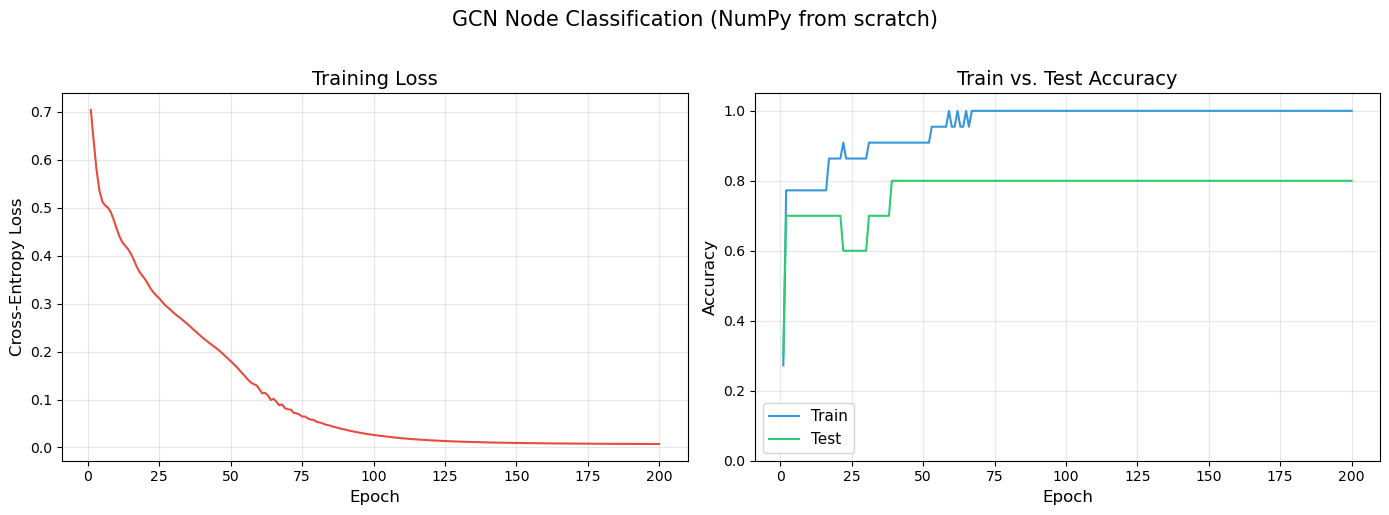

In [20]:
# ==============================================================
# Training Curves
# ==============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(range(1, NUM_EPOCHS + 1), train_losses, color='#e74c3c', linewidth=1.5)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax1.set_title('Training Loss', fontsize=14)
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(range(1, NUM_EPOCHS + 1), train_accs, label='Train', linewidth=1.5, color='#3498db')
ax2.plot(range(1, NUM_EPOCHS + 1), test_accs, label='Test', linewidth=1.5, color='#2ecc71')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Train vs. Test Accuracy', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.suptitle('GCN Node Classification (NumPy from scratch)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Link Prediction from Scratch

Link prediction asks: given the current graph, which pairs of nodes are likely to be connected but are not yet? The approach:

1. Use the GCN to produce node embeddings
2. Score each potential edge with a dot product: `score(u, v) = sigmoid(z_u . z_v)`
3. Train with positive edges (existing) and negative edges (randomly sampled non-edges)
4. Loss: binary cross-entropy

In [21]:
# ==============================================================
# Sigmoid and Binary Cross-Entropy
# ==============================================================

def sigmoid(x):
    """Numerically stable sigmoid."""
    return np.where(
        x >= 0,
        1.0 / (1.0 + np.exp(-x)),
        np.exp(x) / (1.0 + np.exp(x))
    )

def binary_cross_entropy(scores, labels):
    """BCE loss. scores are raw logits, labels are 0 or 1."""
    eps = 1e-12
    p = sigmoid(scores)
    return -np.mean(labels * np.log(p + eps) + (1 - labels) * np.log(1 - p + eps))

def bce_grad(scores, labels):
    """Gradient of BCE w.r.t. scores (logits)."""
    p = sigmoid(scores)
    return (p - labels) / len(labels)


# Quick test
print(f'sigmoid(0) = {sigmoid(0):.4f}  (should be 0.5)')
print(f'sigmoid(5) = {sigmoid(5):.4f}  (should be ~0.993)')
print(f'sigmoid(-5) = {sigmoid(-5):.4f}  (should be ~0.007)')

sigmoid(0) = 0.5000  (should be 0.5)
sigmoid(5) = 0.9933  (should be ~0.993)
sigmoid(-5) = 0.0067  (should be ~0.007)


In [22]:
# ==============================================================
# Sample Positive and Negative Edges
# ==============================================================

edges_set = set(logistics_graph.edges())
edges_set.update((v, u) for u, v in logistics_graph.edges())  # both directions

pos_src = []
pos_dst = []
for u, v in logistics_graph.edges():
    i, j = node_to_idx[u], node_to_idx[v]
    pos_src.extend([i, j])
    pos_dst.extend([j, i])

pos_src = np.array(pos_src)
pos_dst = np.array(pos_dst)

# Sample same number of negative edges (non-existing pairs)
num_neg = len(pos_src)
neg_src = []
neg_dst = []
while len(neg_src) < num_neg:
    i = np.random.randint(0, N)
    j = np.random.randint(0, N)
    if i != j and (node_list[i], node_list[j]) not in edges_set:
        neg_src.append(i)
        neg_dst.append(j)

neg_src = np.array(neg_src)
neg_dst = np.array(neg_dst)

print(f'Positive edges: {len(pos_src)}')
print(f'Negative edges: {len(neg_src)}')

Positive edges: 70
Negative edges: 70


In [23]:
# ==============================================================
# Link Prediction Model and Training
# ==============================================================
#
# Architecture: 2-layer GCN encoder + dot-product decoder
# The encoder produces embeddings, the decoder scores node pairs.

class LinkPredModel:
    """GCN encoder + dot-product decoder for link prediction."""

    def __init__(self, in_features, hidden, out_features):
        self.layer1 = GCNLayer(in_features, hidden, activation=True)
        self.layer2 = GCNLayer(hidden, out_features, activation=False)
        self.layers = [self.layer1, self.layer2]

    def encode(self, A_hat, X):
        """Produce node embeddings [N, out_features]."""
        H = self.layer1.forward(A_hat, X)
        Z = self.layer2.forward(A_hat, H)
        return Z

    def decode(self, Z, src, dst):
        """Dot-product scoring: score = z_src . z_dst for each pair."""
        return (Z[src] * Z[dst]).sum(axis=1)


# Initialize link prediction model
np.random.seed(123)
link_model = LinkPredModel(in_features=15, hidden=32, out_features=16)
link_optimizer = AdamOptimizer(link_model.layers, lr=0.01, weight_decay=0.0)

link_losses = []
link_accs = []
LINK_EPOCHS = 200

print('Training link prediction model (NumPy only)')
print('=' * 60)

for epoch in range(1, LINK_EPOCHS + 1):
    # --- Encode ---
    Z = link_model.encode(A_hat, X)

    # --- Decode: score positive and negative edges ---
    pos_scores = link_model.decode(Z, pos_src, pos_dst)
    neg_scores = link_model.decode(Z, neg_src, neg_dst)

    all_scores = np.concatenate([pos_scores, neg_scores])
    all_labels = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])

    # --- Loss ---
    loss = binary_cross_entropy(all_scores, all_labels)

    # --- Backward through decoder and encoder ---
    # Gradient of BCE w.r.t. scores
    d_all = bce_grad(all_scores, all_labels)
    d_pos = d_all[:len(pos_scores)]
    d_neg = d_all[len(pos_scores):]

    # Gradient w.r.t. embeddings Z
    dZ = np.zeros_like(Z)
    # Positive edges: d(score)/dZ[src] = Z[dst] * d_score, and vice versa
    for k in range(len(pos_src)):
        dZ[pos_src[k]] += Z[pos_dst[k]] * d_pos[k]
        dZ[pos_dst[k]] += Z[pos_src[k]] * d_pos[k]
    for k in range(len(neg_src)):
        dZ[neg_src[k]] += Z[neg_dst[k]] * d_neg[k]
        dZ[neg_dst[k]] += Z[neg_src[k]] * d_neg[k]

    # Backprop through encoder layers
    dH = link_model.layer2.backward(A_hat, dZ)
    dH = link_model.layer1.backward(A_hat, dH)

    # --- Update weights ---
    link_optimizer.step()

    # --- Accuracy ---
    preds = (sigmoid(all_scores) > 0.5).astype(float)
    acc = (preds == all_labels).mean()

    link_losses.append(loss)
    link_accs.append(acc)

    if epoch % 50 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}  |  Loss: {loss:.4f}  |  Acc: {acc:.3f}')

print(f'\nFinal link prediction accuracy: {link_accs[-1]:.3f}')

Training link prediction model (NumPy only)
Epoch   1  |  Loss: 0.6728  |  Acc: 0.507
Epoch  50  |  Loss: 0.2893  |  Acc: 0.864
Epoch 100  |  Loss: 0.1361  |  Acc: 0.943
Epoch 150  |  Loss: 0.0310  |  Acc: 1.000
Epoch 200  |  Loss: 0.0075  |  Acc: 1.000

Final link prediction accuracy: 1.000


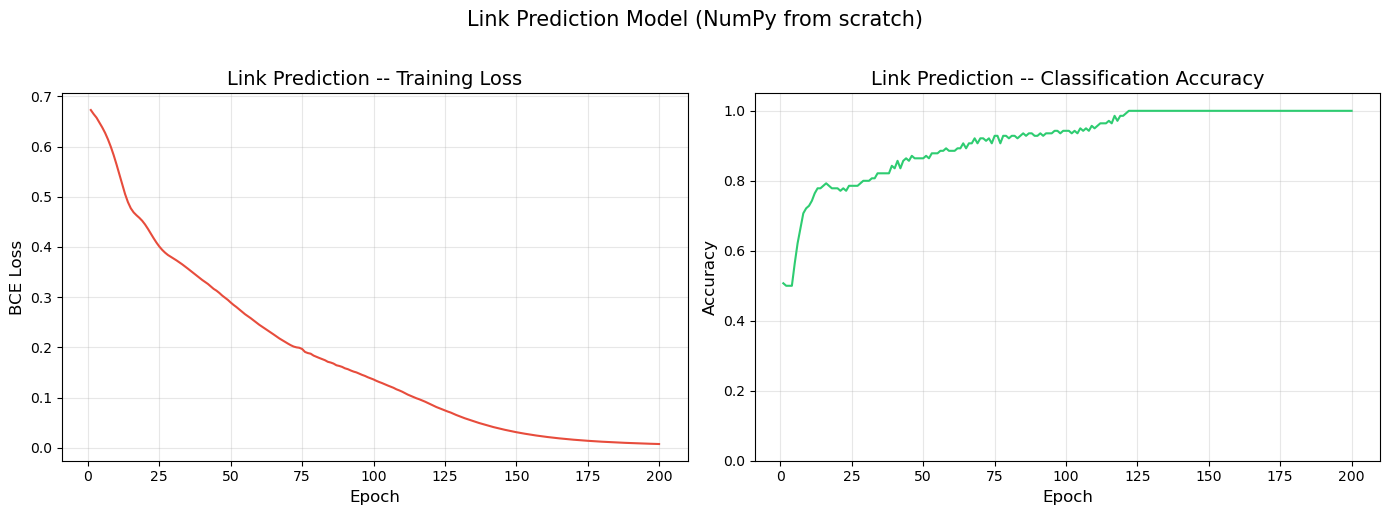

In [24]:
# ==============================================================
# Link Prediction Training Curves
# ==============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, LINK_EPOCHS + 1), link_losses, color='#e74c3c', linewidth=1.5)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('BCE Loss', fontsize=12)
ax1.set_title('Link Prediction -- Training Loss', fontsize=14)
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, LINK_EPOCHS + 1), link_accs, color='#2ecc71', linewidth=1.5)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Link Prediction -- Classification Accuracy', fontsize=14)
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

plt.suptitle('Link Prediction Model (NumPy from scratch)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Embedding Visualization

We extract the 16-dimensional embeddings from the node classification model's second layer and project them to 2D for visualization. Instead of importing sklearn for t-SNE, we implement PCA from scratch using NumPy's eigendecomposition.

In [25]:
# ==============================================================
# PCA from Scratch
# ==============================================================

def pca_2d(data):
    """Project data to 2 dimensions using PCA (from scratch).

    data: [N, D] matrix
    Returns: [N, 2] matrix
    """
    # Center the data
    centered = data - data.mean(axis=0)

    # Covariance matrix
    cov = (centered.T @ centered) / (centered.shape[0] - 1)

    # Eigendecomposition (eigh returns sorted ascending)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Take the top 2 eigenvectors (largest eigenvalues are at the end)
    top2 = eigenvectors[:, -2:][:, ::-1]

    # Project
    return centered @ top2


# Extract embeddings from the trained node classification model
embeddings = model.get_embeddings(A_hat, X)
print(f'Embedding matrix shape: {embeddings.shape}')

# Project to 2D
embeddings_2d = pca_2d(embeddings)
print(f'Projected shape: {embeddings_2d.shape}')

Embedding matrix shape: (32, 16)
Projected shape: (32, 2)


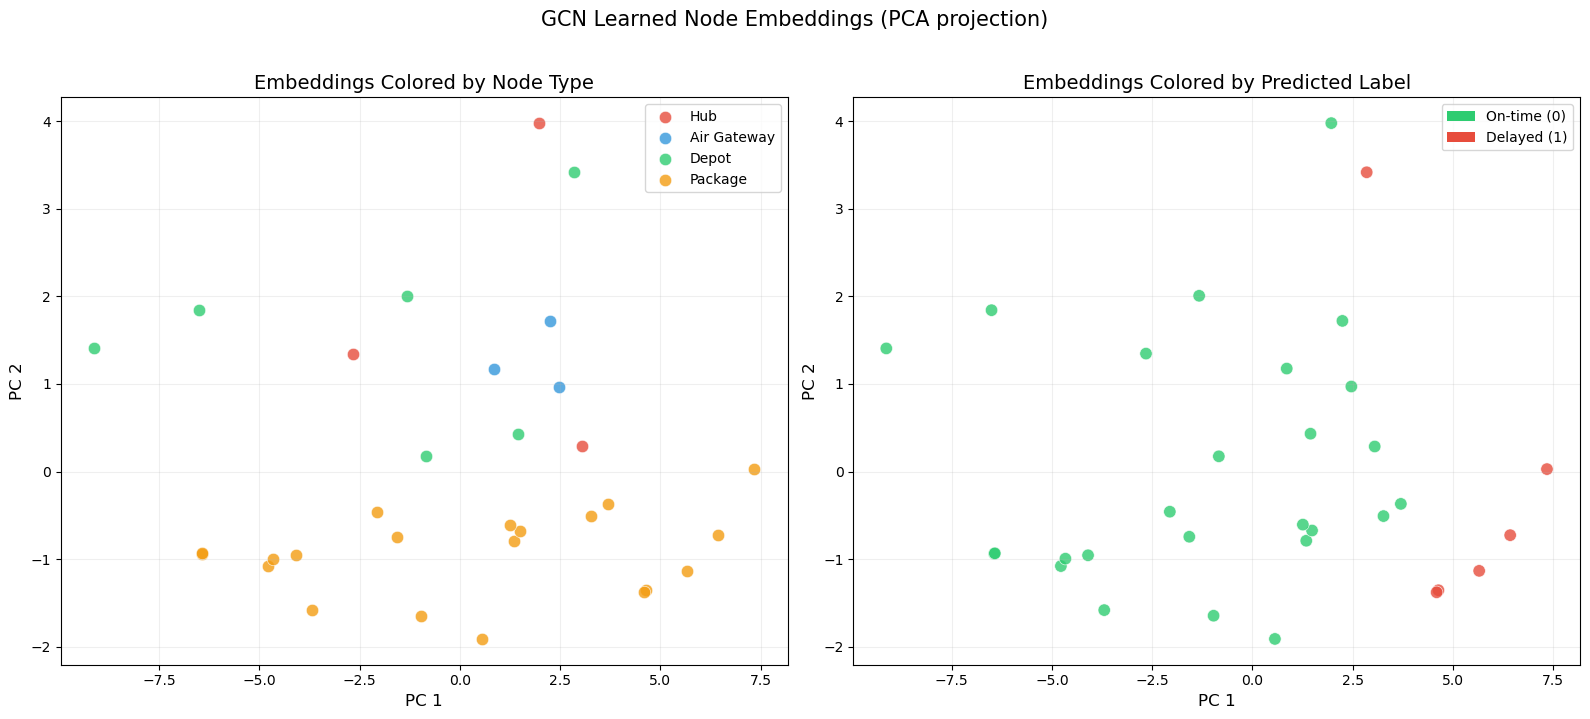

In [26]:
# ==============================================================
# Plot Learned Embeddings
# ==============================================================

type_colors = {
    'hub':         '#e74c3c',
    'air_gateway': '#3498db',
    'depot':       '#2ecc71',
    'package':     '#f39c12',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: Colored by node type ---
for ntype, color in type_colors.items():
    mask = [logistics_graph.nodes[node_list[i]].get('type', 'package') == ntype
            for i in range(N)]
    mask = np.array(mask)
    ax1.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
               c=color, label=ntype.replace('_', ' ').title(),
               s=80, alpha=0.8, edgecolors='white', linewidth=0.5)

ax1.set_xlabel('PC 1', fontsize=12)
ax1.set_ylabel('PC 2', fontsize=12)
ax1.set_title('Embeddings Colored by Node Type', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.2)

# --- Plot 2: Colored by predicted label ---
final_probs = model.forward(A_hat, X)
final_preds = final_probs.argmax(axis=1)

colors_pred = ['#2ecc71' if p == 0 else '#e74c3c' for p in final_preds]
ax2.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
            c=colors_pred, s=80, alpha=0.8,
            edgecolors='white', linewidth=0.5)

legend_pred = [Patch(facecolor='#2ecc71', label='On-time (0)'),
               Patch(facecolor='#e74c3c', label='Delayed (1)')]
ax2.set_xlabel('PC 1', fontsize=12)
ax2.set_ylabel('PC 2', fontsize=12)
ax2.set_title('Embeddings Colored by Predicted Label', fontsize=14)
ax2.legend(handles=legend_pred, fontsize=10)
ax2.grid(True, alpha=0.2)

plt.suptitle('GCN Learned Node Embeddings (PCA projection)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

---

## What We Built vs. What PyTorch Provides

| Component | This Notebook (NumPy) | Main Notebook (PyTorch/PyG) |
|-----------|----------------------|----------------------------|
| GCN layer | `A_hat @ H @ W + b` (explicit matrix ops) | `GCNConv(in, out)` (one line) |
| Activation | `np.maximum(0, x)` | `F.relu(x)` |
| Loss | Manual softmax + cross-entropy | `F.nll_loss(...)` |
| Backprop | Hand-derived gradients per layer | `loss.backward()` (autograd) |
| Optimizer | Adam with manual moment tracking | `torch.optim.Adam(...)` |
| Training | NumPy arrays, explicit masks | PyG Data object, GPU-ready |
| Link prediction | Manual dot-product decoder + BCE backprop | PyG negative sampling + autograd |
| Visualization | PCA via eigendecomposition | sklearn t-SNE |

Both produce the same results. The difference is abstraction level, not capability. PyTorch and PyG are the right choice for production work and large-scale experiments -- they handle GPU acceleration, automatic differentiation, and efficient sparse operations. But now you know exactly what those abstractions are doing under the hood.

### What to do next

1. **Read the main notebook** (`Knowledge_Graph_GNN_Neo4j_Guide.ipynb`) for the full theoretical treatment of GCN, GraphSAGE, and GAT architectures.

2. **Move to PyTorch Geometric** for your real projects. Now that you understand what `GCNConv` is doing internally, you can use it confidently without it being a black box.

3. **Read the original papers** -- with the math from this notebook fresh in your mind, the GCN paper (Kipf & Welling, 2017) and the GAT paper (Velickovic et al., 2018) will be much more accessible.

4. **Experiment**: Try changing the number of layers, the hidden dimensions, or the learning rate in this notebook. Because everything is exposed, you can add print statements inside the backward pass to watch gradients flow through the graph. That kind of inspection is much harder with autograd.